In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu

In [3]:
df = pd.read_excel('data/working_dataset.xlsx')

# Analyse Bivarié

## Variables Qualitatives

### DEFAUT x INDLIB_GROUPE

In [4]:
variable = 'INDLIB_GROUPE'
target = 'DEFAUT'

In [5]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Combiner effectifs et pourcentages
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
INDLIB_GROUPE,,
Agriculture/Élevage,7737 (62.99%),4545 (37.01%)
Autres,1438 (82.88%),297 (17.12%)
BTP/Construction,248 (48.44%),264 (51.56%)
Commerce,1922 (23.5%),6256 (76.5%)
Industrie,389 (52.28%),355 (47.72%)
Services,639 (30.84%),1433 (69.16%)
Transport,58 (36.94%),99 (63.06%)


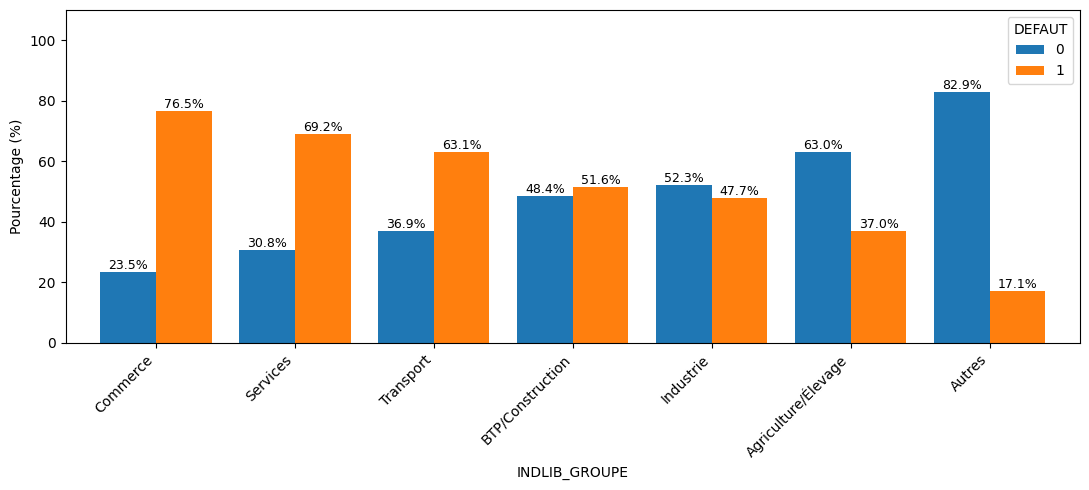

In [6]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(11, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel(variable)
plt.ylabel('Pourcentage (%)')
# plt.title(f'Distribution de {target} selon {variable}')
plt.xticks(rotation=45, ha='right')
plt.legend(title=target)
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [7]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print(f"Conclusion : Il existe une relation significative entre {variable} et {target}.")
else:
    print(f"Conclusion : Il n'existe pas de relation significative entre {variable} et {target}.")

Statistique Chi-square : 4174.537
p-value : 0.0
Degrés de liberté : 6
Conclusion : Il existe une relation significative entre INDLIB_GROUPE et DEFAUT.


In [8]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.4019
Interprétation : La force de la relation est modérée.


### DEFAUT x PORTEF

In [7]:
variable = 'PORTEF'
target = 'DEFAUT'

In [8]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
PORTEF,,
CAM,6721 (91.82%),599 (8.18%)
DD,50 (58.82%),35 (41.18%)
DDC,1601 (89.74%),183 (10.26%)
FSE,2918 (43.25%),3829 (56.75%)
PP,967 (11.21%),7659 (88.79%)
PROJ_M_AV,61 (11.55%),467 (88.45%)
PROPEP,113 (19.15%),477 (80.85%)


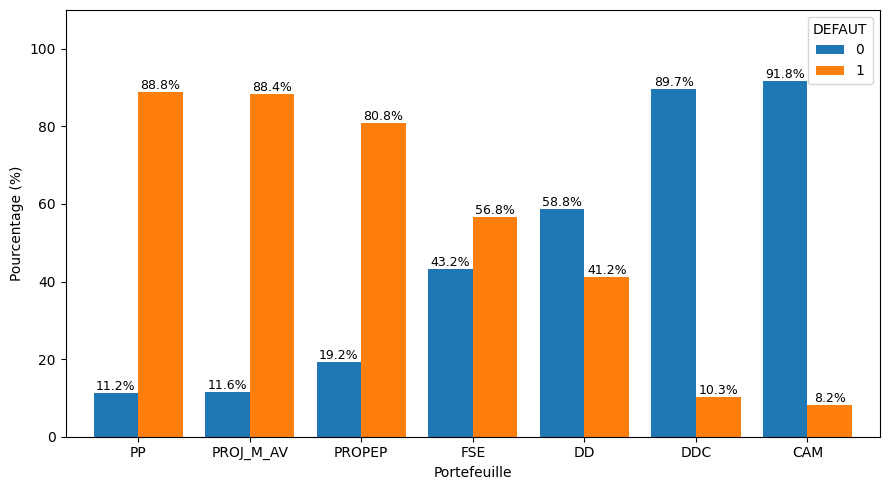

In [10]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel('Portefeuille')
plt.ylabel('Pourcentage (%)')
# plt.title('Distribution du défaut selon le portefeuille')
plt.xticks(rotation=0)
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [14]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre PORTEF et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre PORTEF et DEFAUT.")

Statistique Chi-square : 12161.0667
p-value : 0.0
Degrés de liberté : 6
Conclusion : Il existe une relation significative entre PORTEF et DEFAUT.


In [15]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.6859
Interprétation : La force de la relation est forte.


### DEFAUT x PERIODE

In [11]:
variable = 'PERIODE'
target = 'DEFAUT'

In [12]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
PERIODE,,
M,5829 (31.5%),12674 (68.5%)
S,6543 (93.24%),474 (6.76%)
T,59 (36.88%),101 (63.12%)


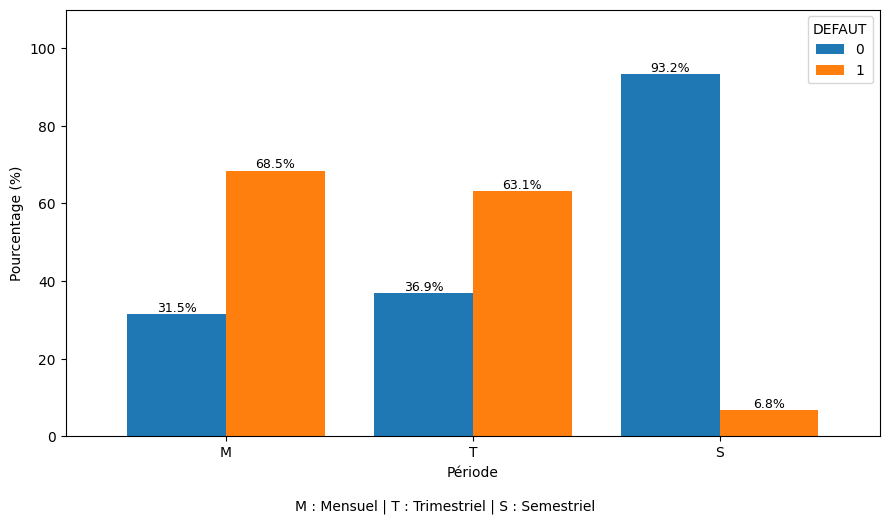

In [14]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel('Période')
plt.ylabel('Pourcentage (%)')
# plt.title('Distribution du défaut selon la période')
plt.xticks(rotation=0)
plt.legend(title='DEFAUT')
plt.ylim(0, 110)

plt.figtext(
    0.5, -0.03,
    "M : Mensuel | T : Trimestriel | S : Semestriel",
    ha='center',
    fontsize=10
)

plt.tight_layout()
plt.show()

In [15]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre PERIODE et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre PERIODE et DEFAUT.")

Statistique Chi-square : 7774.1715
p-value : 0.0
Degrés de liberté : 2
Conclusion : Il existe une relation significative entre PERIODE et DEFAUT.


In [16]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.5502
Interprétation : La force de la relation est forte.


### DEFAUT x SEX

In [17]:
variable = 'SEX'
target = 'DEFAUT'

In [18]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
SEX,,
Female,2892 (31.09%),6411 (68.91%)
Male,9539 (58.25%),6838 (41.75%)


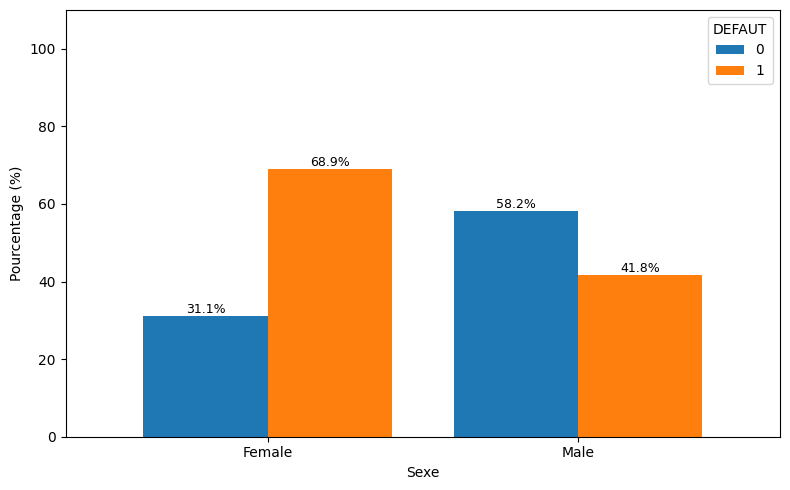

In [20]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(8, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel('Sexe')
plt.ylabel('Pourcentage (%)')
# plt.title('Distribution du défaut selon le sexe')
plt.xticks(rotation=0)
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [28]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre SEX et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre SEX et DEFAUT.")

Statistique Chi-square : 1759.5341
p-value : 0.0
Degrés de liberté : 1
Conclusion : Il existe une relation significative entre SEX et DEFAUT.


In [29]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.2609
Interprétation : La force de la relation est faible.


### DEFAUT x AGENCE_LIEU

In [21]:
variable = 'AGENCE_LIEU'
target = 'DEFAUT'

In [22]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
AGENCE_LIEU,,
Adrar,470 (40.34%),695 (59.66%)
Assaba,202 (13.25%),1322 (86.75%)
Brakna,953 (33.49%),1893 (66.51%)
Dakhlet Nouadhibou,607 (59.45%),414 (40.55%)
Gorgol,1577 (47.59%),1737 (52.41%)
Guidimagha,139 (11.64%),1055 (88.36%)
Hodh Chargui,264 (14.87%),1511 (85.13%)
Hodh Gharbi,210 (16.17%),1089 (83.83%)
Inchiri,130 (17.81%),600 (82.19%)


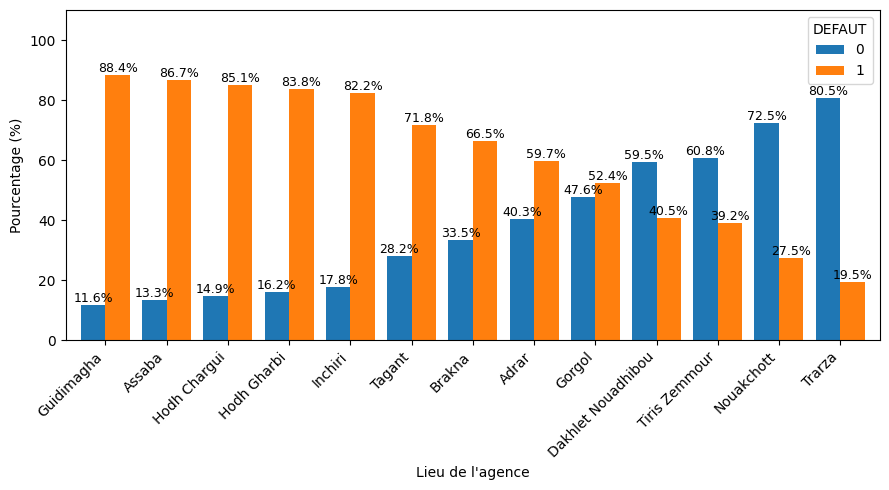

In [23]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel("Lieu de l'agence")
plt.ylabel('Pourcentage (%)')
# plt.title("Distribution du défaut selon le lieu de l'agence")
plt.xticks(rotation=45, ha='right')
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [33]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre AGENCE_LIEU et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre AGENCE_LIEU et DEFAUT.")

Statistique Chi-square : 6969.6235
p-value : 0.0
Degrés de liberté : 12
Conclusion : Il existe une relation significative entre AGENCE_LIEU et DEFAUT.


In [34]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.5193
Interprétation : La force de la relation est forte.


### DEFAUT x ETATCIVIL

In [43]:
variable = 'ETATCIVIL'
target = 'DEFAUT'

In [44]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
ETATCIVIL,,
Divorced,241 (25.61%),700 (74.39%)
Married,10416 (53.26%),9140 (46.74%)
Single,1774 (34.23%),3409 (65.77%)


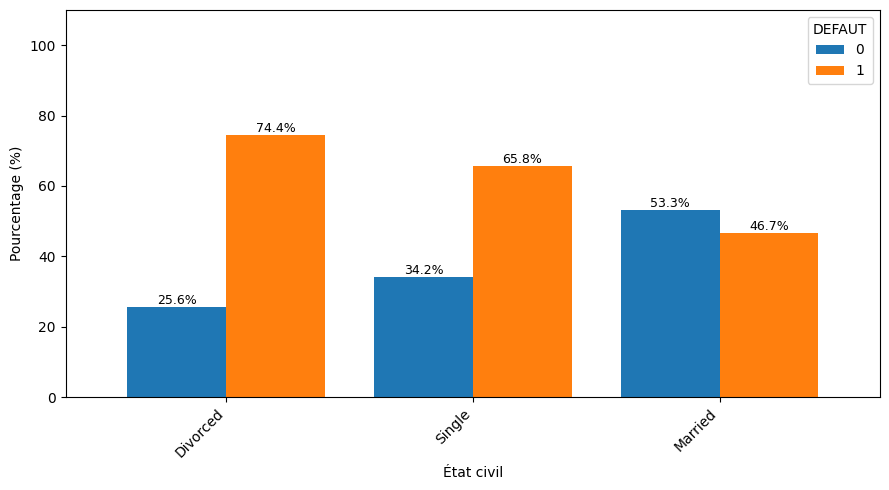

In [45]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(9, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=9
    )

plt.xlabel("État civil")
plt.ylabel("Pourcentage (%)")
# plt.title("Distribution du défaut selon l’état civil")
plt.xticks(rotation=45, ha='right')
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [39]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :", p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre ETATCIVIL et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre ETATCIVIL et DEFAUT.")

Statistique Chi-square : 808.1055
p-value : 3.327524454192334e-176
Degrés de liberté : 2
Conclusion : Il existe une relation significative entre ETATCIVIL et DEFAUT.


In [40]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.1768
Interprétation : La force de la relation est faible.


### DEFAUT x WILAYA_NAISSANCE

In [46]:
variable = 'WILAYA_NAISSANCE'
target = 'DEFAUT'

In [47]:
# Table des effectifs
table_count = pd.crosstab(df[variable], df[target])

# Table des pourcentages par ligne
table_pct = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100).round(2)

# Tableau final : effectif (pourcentage)
table_finale = (
    table_count.astype(str)
    + " ("
    + table_pct.astype(str)
    + "%)"
)

table_finale

DEFAUT,0,1
WILAYA_NAISSANCE,,
Adrar,849 (55.06%),693 (44.94%)
Assaba,506 (26.99%),1369 (73.01%)
Brakna,1328 (42.87%),1770 (57.13%)
Gorgol,1606 (50.63%),1566 (49.37%)
Guidimakha,269 (20.77%),1026 (79.23%)
Hodh Ech Chargui,371 (19.89%),1494 (80.11%)
Hodh el Gharbi,399 (64.56%),219 (35.44%)
Inchiri,184 (22.6%),630 (77.4%)
Inconnu,2398 (58.75%),1684 (41.25%)


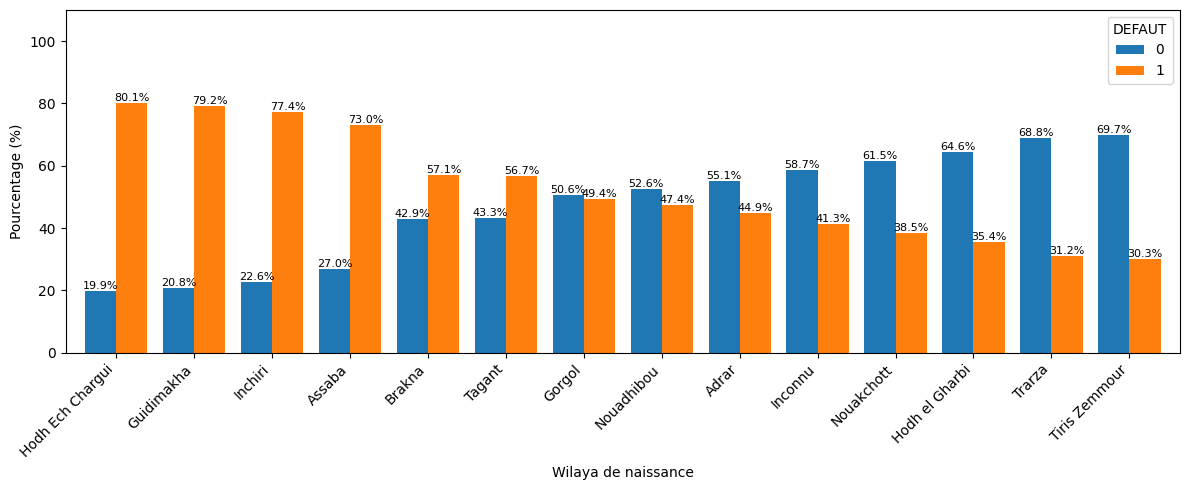

In [48]:
# Préparer les pourcentages
table_pct_graph = pd.crosstab(
    df[variable],
    df[target],
    normalize='index'
).mul(100)

# Trier selon le taux de défaut = 1
table_pct_graph = table_pct_graph.sort_values(by=1, ascending=False)

# Graphique
ax = table_pct_graph.plot(
    kind='bar',
    figsize=(12, 5),
    width=0.8
)

# Ajouter les pourcentages sur les barres
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='edge',
        fontsize=8
    )

plt.xlabel("Wilaya de naissance")
plt.ylabel("Pourcentage (%)")
# plt.title("Distribution du défaut selon la wilaya de naissance")
plt.xticks(rotation=45, ha='right')
plt.legend(title='DEFAUT')
plt.ylim(0, 110)
plt.tight_layout()
plt.show()

In [44]:
chi2, p_value, dof, expected = chi2_contingency(table_count)

print("Statistique Chi-square :", round(chi2, 4))
print("p-value :",p_value)
print("Degrés de liberté :", dof)

if p_value < 0.05:
    print("Conclusion : Il existe une relation significative entre WILAYA_NAISSANCE et DEFAUT.")
else:
    print("Conclusion : Il n'existe pas de relation significative entre WILAYA_NAISSANCE et DEFAUT.")

Statistique Chi-square : 2701.0157
p-value : 0.0
Degrés de liberté : 13
Conclusion : Il existe une relation significative entre WILAYA_NAISSANCE et DEFAUT.


In [45]:
n = table_count.sum().sum()
r, k = table_count.shape

cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("Cramér's V :", round(cramers_v, 4))

if cramers_v < 0.1:
    interpretation = "très faible"
elif cramers_v < 0.3:
    interpretation = "faible"
elif cramers_v < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La force de la relation est {interpretation}.")

Cramér's V : 0.3233
Interprétation : La force de la relation est modérée.


In [46]:
df.duplicated().sum()

np.int64(172)

## Variables Quantitatives

### DEFAUT x MONTANT

In [33]:
variable = 'MONTANT'
target = 'DEFAUT'

# Convertir MONTANT en numérique
df[variable] = pd.to_numeric(df[variable], errors='coerce')

# Garder seulement les lignes utiles
data = df[[variable, target]].dropna()

# Garder seulement DEFAUT = 0 et DEFAUT = 1
data = data[data[target].isin([0, 1])]

In [34]:
summary_montant = data.groupby(target)[variable].agg(
    Effectif='count',
    Moyenne='mean',
    Médiane='median',
    Minimum='min',
    Maximum='max',
    Ecart_type='std'
).round(2)

summary_montant

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
DEFAUT,,,,,,
0,12431,170496.90,59260.0,10000.0,83010000.0,1088676.40
1,13249,102749.64,20000.0,10000.0,41018069.0,937287.77


<Figure size 800x500 with 0 Axes>

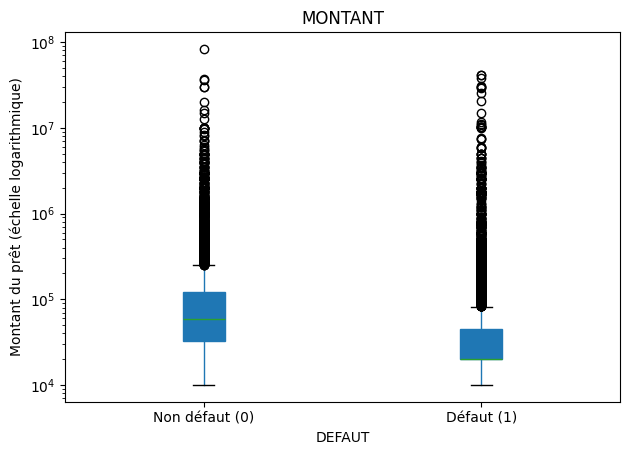

In [35]:
plt.figure(figsize=(8, 5))

data.boxplot(
    column=variable,
    by=target,
    grid=False,
    patch_artist=True
)

plt.yscale('log')

# plt.title('Distribution du montant selon le défaut')
plt.suptitle('')
plt.xlabel('DEFAUT')
plt.ylabel('Montant du prêt (échelle logarithmique)')
plt.xticks([1, 2], ['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

In [10]:
groupe_0 = data.loc[data[target] == 0, variable]
groupe_1 = data.loc[data[target] == 1, variable]

stat, p_value = mannwhitneyu(
    groupe_0,
    groupe_1,
    alternative='two-sided'
)

print("Statistique Mann-Whitney U :", round(stat, 4))
print("p-value :", p_value)

if p_value < 0.05:
    print("Conclusion : Il existe une différence significative du montant entre les clients en défaut et les clients non en défaut.")
else:
    print("Conclusion : Il n'existe pas de différence significative du montant entre les clients en défaut et les clients non en défaut.")

Statistique Mann-Whitney U : 121645568.0
p-value : 0.0
Conclusion : Il existe une différence significative du montant entre les clients en défaut et les clients non en défaut.


In [11]:
n0 = len(groupe_0)
n1 = len(groupe_1)

rank_biserial = (2 * stat) / (n0 * n1) - 1

print("Rank-biserial correlation :", round(rank_biserial, 4))

abs_effect = abs(rank_biserial)

if abs_effect < 0.1:
    interpretation = "très faible"
elif abs_effect < 0.3:
    interpretation = "faible"
elif abs_effect < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La taille de l'effet est {interpretation}.")

Rank-biserial correlation : 0.4772
Interprétation : La taille de l'effet est modérée.


### DEFAUT x DUREE

In [36]:
variable = 'DUREE'
target = 'DEFAUT'

# Convertir DUREE en numérique
df[variable] = pd.to_numeric(df[variable], errors='coerce')

# Garder seulement les lignes utiles
data = df[[variable, target]].dropna()

# Garder seulement DEFAUT = 0 et DEFAUT = 1
data = data[data[target].isin([0, 1])]

In [37]:
summary_duree = data.groupby(target)[variable].agg(
    Effectif='count',
    Moyenne='mean',
    Médiane='median',
    Minimum='min',
    Maximum='max',
    Ecart_type='std'
).round(2)

summary_duree

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
DEFAUT,,,,,,
0,12431,18.17,6.0,1,96,14.79
1,13249,34.68,36.0,1,96,7.18


<Figure size 800x500 with 0 Axes>

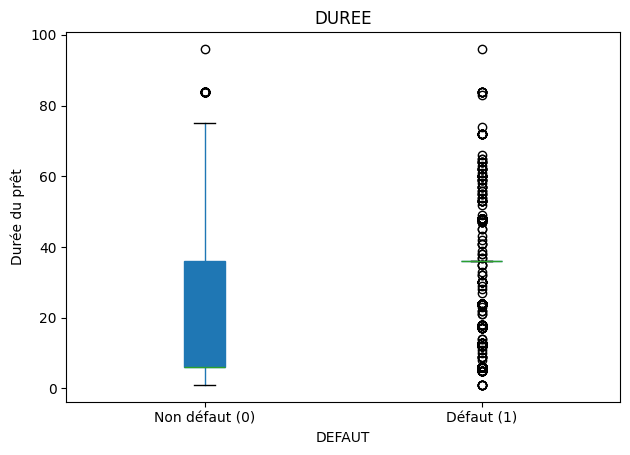

In [39]:
plt.figure(figsize=(8, 5))

data.boxplot(
    column=variable,
    by=target,
    grid=False,
    patch_artist=True
)

# plt.title('Distribution de la durée selon le défaut')
plt.suptitle('')
plt.xlabel('DEFAUT')
plt.ylabel('Durée du prêt')
plt.xticks([1, 2], ['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

In [16]:
groupe_0 = data.loc[data[target] == 0, variable]
groupe_1 = data.loc[data[target] == 1, variable]

stat, p_value = mannwhitneyu(
    groupe_0,
    groupe_1,
    alternative='two-sided'
)

print("Statistique Mann-Whitney U :", round(stat, 4))
print("p-value :", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion : Il existe une différence significative de la durée entre les clients en défaut et les clients non en défaut.")
else:
    print("Conclusion : Il n'existe pas de différence significative de la durée entre les clients en défaut et les clients non en défaut.")

Statistique Mann-Whitney U : 33961358.0
p-value : 0.0
Conclusion : Il existe une différence significative de la durée entre les clients en défaut et les clients non en défaut.


In [17]:
n0 = len(groupe_0)
n1 = len(groupe_1)

rank_biserial = (2 * stat) / (n0 * n1) - 1

print("Rank-biserial correlation :", round(rank_biserial, 4))

abs_effect = abs(rank_biserial)

if abs_effect < 0.1:
    interpretation = "très faible"
elif abs_effect < 0.3:
    interpretation = "faible"
elif abs_effect < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La taille de l'effet est {interpretation}.")

Rank-biserial correlation : -0.5876
Interprétation : La taille de l'effet est forte.


### DEFAUT x TAUX_INT

In [40]:
variable = 'TAUX_INT'
target = 'DEFAUT'

# Convertir TAUX_INT en numérique
df[variable] = pd.to_numeric(df[variable], errors='coerce')

# Garder seulement les lignes utiles
data = df[[variable, target]].dropna()

# Garder seulement DEFAUT = 0 et DEFAUT = 1
data = data[data[target].isin([0, 1])]

In [41]:
summary_taux_int = data.groupby(target)[variable].agg(
    Effectif='count',
    Moyenne='mean',
    Médiane='median',
    Minimum='min',
    Maximum='max',
    Ecart_type='std'
).round(2)

summary_taux_int

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
DEFAUT,,,,,,
0,12431,6.85,6.0,0.0,12.0,4.02
1,13249,4.03,3.0,0.0,12.0,2.20


<Figure size 800x500 with 0 Axes>

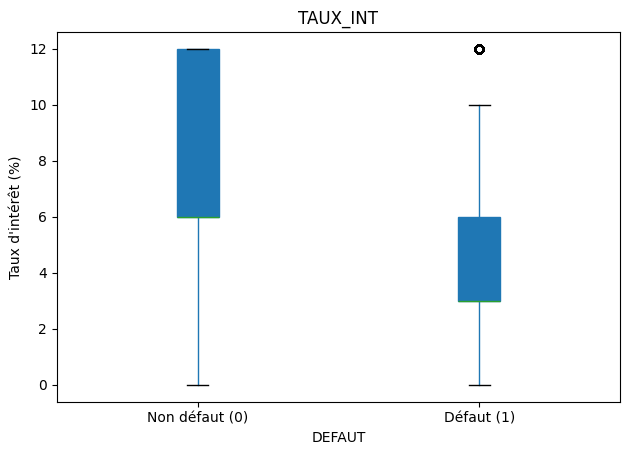

In [42]:
plt.figure(figsize=(8, 5))

data.boxplot(
    column=variable,
    by=target,
    grid=False,
    patch_artist=True
)

# plt.title("Distribution du taux d'intérêt selon le défaut")
plt.suptitle('')
plt.xlabel('DEFAUT')
plt.ylabel("Taux d'intérêt (%)")
plt.xticks([1, 2], ['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

In [21]:
groupe_0 = data.loc[data[target] == 0, variable]
groupe_1 = data.loc[data[target] == 1, variable]

stat, p_value = mannwhitneyu(
    groupe_0,
    groupe_1,
    alternative='two-sided'
)

print("Statistique Mann-Whitney U :", round(stat, 4))
print("p-value :", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion : Il existe une différence significative du taux d'intérêt entre les clients en défaut et les clients non en défaut.")
else:
    print("Conclusion : Il n'existe pas de différence significative du taux d'intérêt entre les clients en défaut et les clients non en défaut.")

Statistique Mann-Whitney U : 119003686.0
p-value : 0.0
Conclusion : Il existe une différence significative du taux d'intérêt entre les clients en défaut et les clients non en défaut.


In [22]:
n0 = len(groupe_0)
n1 = len(groupe_1)

rank_biserial = (2 * stat) / (n0 * n1) - 1

print("Rank-biserial correlation :", round(rank_biserial, 4))

abs_effect = abs(rank_biserial)

if abs_effect < 0.1:
    interpretation = "très faible"
elif abs_effect < 0.3:
    interpretation = "faible"
elif abs_effect < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La taille de l'effet est {interpretation}.")

Rank-biserial correlation : 0.4451
Interprétation : La taille de l'effet est modérée.


### DEFAUT x NB_ECH

In [23]:
variable = 'NB_ECH'
target = 'DEFAUT'

# Convertir NB_ECH en numérique
df[variable] = pd.to_numeric(df[variable], errors='coerce')

# Garder seulement les lignes utiles
data = df[[variable, target]].dropna()

# Garder seulement DEFAUT = 0 et DEFAUT = 1
data = data[data[target].isin([0, 1])]

In [24]:
summary_nb_ech = data.groupby(target)[variable].agg(
    Effectif='count',
    Moyenne='mean',
    Médiane='median',
    Minimum='min',
    Maximum='max',
    Ecart_type='std'
).round(2)

summary_nb_ech

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
DEFAUT,,,,,,
0,12431,15.19,1.0,1,84,16.72
1,13249,34.04,36.0,1,84,8.14


<Figure size 800x500 with 0 Axes>

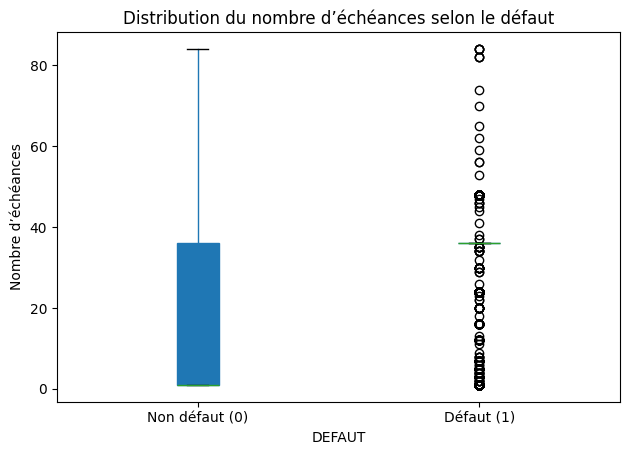

In [25]:
plt.figure(figsize=(8, 5))

data.boxplot(
    column=variable,
    by=target,
    grid=False,
    patch_artist=True
)

plt.title("Distribution du nombre d’échéances selon le défaut")
plt.suptitle('')
plt.xlabel('DEFAUT')
plt.ylabel("Nombre d’échéances")
plt.xticks([1, 2], ['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

In [26]:
groupe_0 = data.loc[data[target] == 0, variable]
groupe_1 = data.loc[data[target] == 1, variable]

stat, p_value = mannwhitneyu(
    groupe_0,
    groupe_1,
    alternative='two-sided'
)

print("Statistique Mann-Whitney U :", round(stat, 4))
print("p-value :", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion : Il existe une différence significative du nombre d’échéances entre les clients en défaut et les clients non en défaut.")
else:
    print("Conclusion : Il n'existe pas de différence significative du nombre d’échéances entre les clients en défaut et les clients non en défaut.")

Statistique Mann-Whitney U : 33692684.0
p-value : 0.0
Conclusion : Il existe une différence significative du nombre d’échéances entre les clients en défaut et les clients non en défaut.


In [27]:
n0 = len(groupe_0)
n1 = len(groupe_1)

rank_biserial = (2 * stat) / (n0 * n1) - 1

print("Rank-biserial correlation :", round(rank_biserial, 4))

abs_effect = abs(rank_biserial)

if abs_effect < 0.1:
    interpretation = "très faible"
elif abs_effect < 0.3:
    interpretation = "faible"
elif abs_effect < 0.5:
    interpretation = "modérée"
else:
    interpretation = "forte"

print(f"Interprétation : La taille de l'effet est {interpretation}.")

Rank-biserial correlation : -0.5909
Interprétation : La taille de l'effet est forte.


### DEFAUT x VALEURGARANT

### DEFAUT x AGE

In [49]:
variable = 'AGE'
target = 'DEFAUT'

# Convertir AGE en numérique
df[variable] = pd.to_numeric(df[variable], errors='coerce')

# Garder seulement les lignes utiles
data = df[[variable, target]].dropna()

# Garder seulement DEFAUT = 0 et DEFAUT = 1
data = data[data[target].isin([0, 1])]

In [50]:
summary_age = data.groupby(target)[variable].agg(
    Effectif='count',
    Moyenne='mean',
    Médiane='median',
    Minimum='min',
    Maximum='max',
    Ecart_type='std'
).round(2)

summary_age

,Effectif,Moyenne,Médiane,Minimum,Maximum,Ecart_type
DEFAUT,,,,,,
0,12431,53.91,53.0,23,90,11.75
1,13249,49.32,49.0,22,90,12.38


<Figure size 800x500 with 0 Axes>

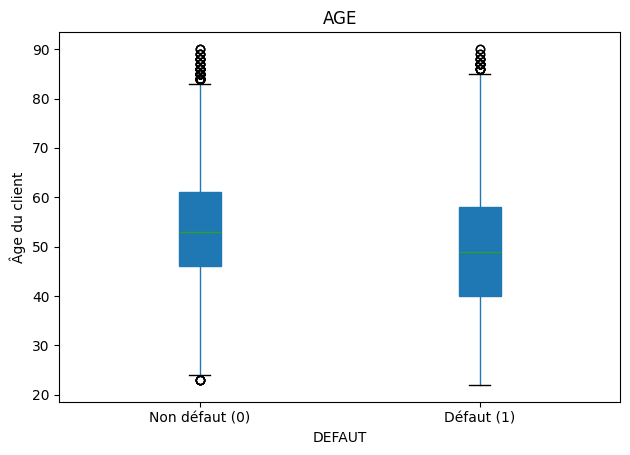

In [51]:
plt.figure(figsize=(8, 5))

data.boxplot(
    column=variable,
    by=target,
    grid=False,
    patch_artist=True
)

# plt.title("Distribution de l’âge selon le défaut")
plt.suptitle('')
plt.xlabel('DEFAUT')
plt.ylabel("Âge du client")
plt.xticks([1, 2], ['Non défaut (0)', 'Défaut (1)'])

plt.tight_layout()
plt.show()

In [32]:
groupe_0 = data.loc[data[target] == 0, variable]
groupe_1 = data.loc[data[target] == 1, variable]

stat, p_value = mannwhitneyu(
    groupe_0,
    groupe_1,
    alternative='two-sided'
)

print("Statistique Mann-Whitney U :", round(stat, 4))
print("p-value :", p_value)

if p_value < 0.05:
    print("Conclusion : Il existe une différence significative de l’âge entre les clients en défaut et les clients non en défaut.")
else:
    print("Conclusion : Il n'existe pas de différence significative de l’âge entre les clients en défaut et les clients non en défaut.")

Statistique Mann-Whitney U : 99051574.0
p-value : 2.997365277028044e-174
Conclusion : Il existe une différence significative de l’âge entre les clients en défaut et les clients non en défaut.
